# Raw Data Validation

Validation of Phase 1 extraction from AACT into local DuckDB.

Checks:
- All 14 tables present with expected row counts
- Status filter applied correctly
- Key distributions (study_type, phase, overall_status)
- Null rates for critical columns
- Join integrity (no orphaned nct_ids)
- Date range sanity

In [1]:
import sys
sys.path.insert(0, '..')

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from config.settings import DUCKDB_PATH
from config.tables import EXTRACT_TABLES

conn = duckdb.connect(str(DUCKDB_PATH), read_only=True)
print(f'Connected to {DUCKDB_PATH}')

Connected to /Users/joshziel/Documents/Coding/clinical-trials/notebooks/../data/clinical_trials.duckdb


## Extraction Metadata

In [2]:
meta_df = conn.execute("""
    SELECT table_name, row_count, duration_seconds, extract_date
    FROM meta.extraction_log
    WHERE extraction_id = (
        SELECT extraction_id FROM meta.extraction_log
        ORDER BY started_at DESC LIMIT 1
    )
    ORDER BY table_name
""").df()

print(f'Extract date: {meta_df["extract_date"].iloc[0]}')
print(f'Tables extracted: {len(meta_df)}')
print(f'Total rows: {meta_df["row_count"].sum():,}')
print(f'Total time: {meta_df["duration_seconds"].sum():.1f}s')
print()
meta_df

Extract date: 2026-04-07 00:00:00
Tables extracted: 14
Total rows: 3,440,145
Total time: 28.0s



,table_name,row_count,duration_seconds,extract_date
0,brief_summaries,118764,2.83,2026-04-07
1,browse_conditions,896534,2.64,2026-04-07
2,browse_interventions,445447,1.36,2026-04-07
3,calculated_values,118764,0.85,2026-04-07
4,conditions,252455,0.83,2026-04-07
5,countries,166193,0.57,2026-04-07
6,design_groups,224067,1.84,2026-04-07
7,designs,118498,0.95,2026-04-07
8,detailed_descriptions,118764,3.93,2026-04-07
9,eligibilities,118764,4.79,2026-04-07


In [3]:
missing = set(EXTRACT_TABLES) - set(meta_df['table_name'])
if missing:
    print(f'WARNING: Missing tables: {missing}')
else:
    print('All 14 expected tables present.')

All 14 expected tables present.


## Row Counts

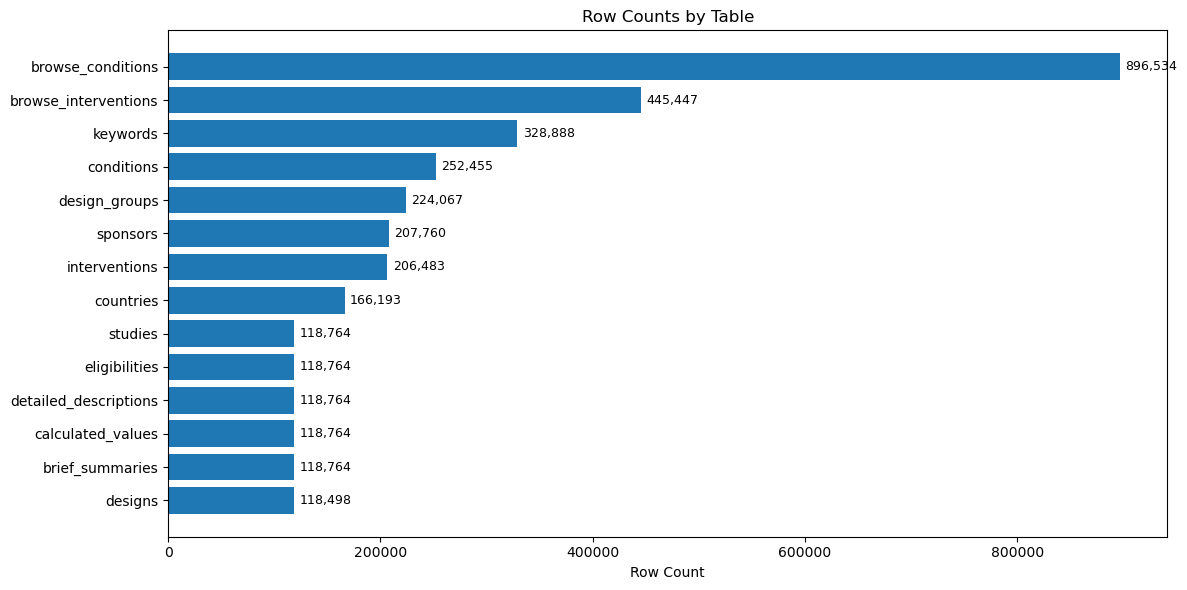

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
meta_sorted = meta_df.sort_values('row_count', ascending=True)
ax.barh(meta_sorted['table_name'], meta_sorted['row_count'])
ax.set_xlabel('Row Count')
ax.set_title('Row Counts by Table')
for i, (_, row) in enumerate(meta_sorted.iterrows()):
    ax.text(row['row_count'] + 5000, i, f"{row['row_count']:,}", va='center', fontsize=9)
plt.tight_layout()
plt.show()

## Status Filter Validation

Confirm only the 5 expected statuses are present in the studies table.

In [5]:
status_df = conn.execute("""
    SELECT overall_status, COUNT(*) as count
    FROM raw.studies
    GROUP BY overall_status
    ORDER BY count DESC
""").df()

print('Overall status distribution:')
print(status_df.to_string(index=False))

expected_statuses = {'RECRUITING', 'NOT_YET_RECRUITING', 'ACTIVE_NOT_RECRUITING',
                     'ENROLLING_BY_INVITATION', 'AVAILABLE'}
actual_statuses = set(status_df['overall_status'])
unexpected = actual_statuses - expected_statuses
if unexpected:
    print(f'\nWARNING: Unexpected statuses: {unexpected}')
else:
    print(f'\nStatus filter correct: only {len(actual_statuses)} expected statuses present.')

Overall status distribution:
         overall_status  count
             RECRUITING  64797
     NOT_YET_RECRUITING  27138
  ACTIVE_NOT_RECRUITING  21514
ENROLLING_BY_INVITATION   5063
              AVAILABLE    252

Status filter correct: only 5 expected statuses present.


## Study Type Distribution

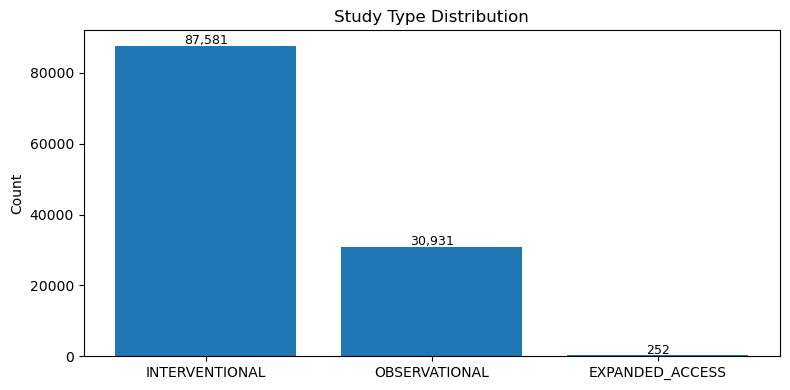

In [6]:
study_type_df = conn.execute("""
    SELECT study_type, COUNT(*) as count
    FROM raw.studies
    GROUP BY study_type
    ORDER BY count DESC
""").df()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(study_type_df['study_type'], study_type_df['count'])
ax.set_title('Study Type Distribution')
ax.set_ylabel('Count')
for i, row in study_type_df.iterrows():
    ax.text(i, row['count'] + 500, f"{row['count']:,}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## Phase Distribution

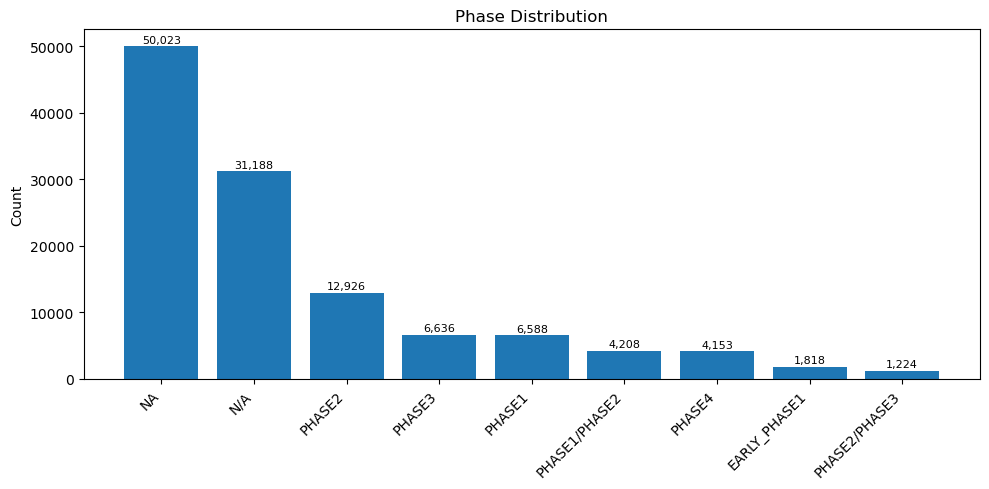

In [7]:
phase_df = conn.execute("""
    SELECT COALESCE(phase, 'N/A') as phase, COUNT(*) as count
    FROM raw.studies
    GROUP BY phase
    ORDER BY count DESC
""").df()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(phase_df['phase'], phase_df['count'])
ax.set_title('Phase Distribution')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
for i, row in phase_df.iterrows():
    ax.text(i, row['count'] + 500, f"{row['count']:,}", ha='center', fontsize=8)
plt.tight_layout()
plt.show()

## Null Rate Analysis

Check null rates for key columns in studies, designs, and eligibilities.

In [8]:
def null_rates(table_name, conn):
    """Compute null rate for each column in a table."""
    cols = conn.execute(
        f"SELECT column_name FROM information_schema.columns "
        f"WHERE table_schema='raw' AND table_name='{table_name}'"
    ).fetchall()
    total = conn.execute(f'SELECT COUNT(*) FROM raw.{table_name}').fetchone()[0]
    results = []
    for (col,) in cols:
        nulls = conn.execute(
            f'SELECT COUNT(*) FROM raw.{table_name} WHERE "{col}" IS NULL'
        ).fetchone()[0]
        pct = round(100 * nulls / total, 1) if total > 0 else 0
        results.append({'column': col, 'null_count': nulls, 'null_pct': pct})
    return pd.DataFrame(results).sort_values('null_pct', ascending=False)

for table in ['studies', 'designs', 'eligibilities']:
    print(f'\n{"="*60}')
    print(f'Null rates for raw.{table}')
    print(f'{"="*60}')
    nr = null_rates(table, conn)
    non_zero = nr[nr['null_pct'] > 0]
    if len(non_zero) > 0:
        print(non_zero.to_string(index=False))
    else:
        print('No null values found.')
    print(f'\nColumns with 0% nulls: {len(nr) - len(non_zero)} / {len(nr)}')


Null rates for raw.studies
                             column  null_count  null_pct
                            is_ppsd      118753     100.0
                    delayed_posting      118764     100.0
      nlm_download_date_description      118764     100.0
                        why_stopped      118764     100.0
     expanded_access_type_treatment      118709     100.0
disposition_first_submitted_qc_date      118734     100.0
                  last_known_status      118764     100.0
                 fdaaa801_violation      118764     100.0
       baseline_type_units_analyzed      118762     100.0
            limitations_and_caveats      118634      99.9
      disposition_first_posted_date      118588      99.9
 disposition_first_posted_date_type      118588      99.9
  expanded_access_type_intermediate      118686      99.9
    expanded_access_type_individual      118670      99.9
              expanded_access_nctid      118524      99.8
   expanded_access_status_for_nctid      118

## Join Integrity

Verify that all child tables' nct_ids exist in the studies table (no orphans).

In [9]:
child_tables = [t for t in EXTRACT_TABLES if t != 'studies']

print(f'{"Table":<25} {"Distinct nct_ids":>15} {"Orphans":>10}')
print('-' * 52)

all_ok = True
for table in child_tables:
    result = conn.execute(f"""
        SELECT
            COUNT(DISTINCT t.nct_id) as distinct_ids,
            COUNT(DISTINCT CASE WHEN s.nct_id IS NULL THEN t.nct_id END) as orphans
        FROM raw.{table} t
        LEFT JOIN raw.studies s ON t.nct_id = s.nct_id
    """).fetchone()
    distinct_ids, orphans = result
    status = '' if orphans == 0 else ' WARNING'
    if orphans > 0:
        all_ok = False
    print(f'{table:<25} {distinct_ids:>15,} {orphans:>10}{status}')

print()
if all_ok:
    print('All child tables have valid nct_id references.')
else:
    print('WARNING: Some child tables have orphaned nct_ids.')

Table                     Distinct nct_ids    Orphans
----------------------------------------------------
designs                           118,498          0
conditions                        118,755          0
browse_conditions                  93,465          0
interventions                     105,913          0
browse_interventions               47,462          0
sponsors                          118,764          0
keywords                           73,617          0
brief_summaries                   118,764          0
detailed_descriptions             118,764          0
design_groups                     108,647          0
countries                         106,107          0
eligibilities                     118,764          0
calculated_values                 118,764          0

All child tables have valid nct_id references.


## Date Range Sanity Check

In [10]:
date_df = conn.execute("""
    SELECT
        MIN(start_date) as earliest_start,
        MAX(start_date) as latest_start,
        MIN(study_first_posted_date) as earliest_posted,
        MAX(study_first_posted_date) as latest_posted,
        COUNT(*) as total_studies
    FROM raw.studies
""").df()

print('Date ranges in raw.studies:')
print(f'  Start date:        {date_df["earliest_start"].iloc[0]}  to  {date_df["latest_start"].iloc[0]}')
print(f'  First posted date: {date_df["earliest_posted"].iloc[0]}  to  {date_df["latest_posted"].iloc[0]}')
print(f'  Total studies: {date_df["total_studies"].iloc[0]:,}')

Date ranges in raw.studies:
  Start date:        1964-01-31 00:00:00  to  2050-01-31 00:00:00
  First posted date: 1999-10-19 00:00:00  to  2026-04-06 00:00:00
  Total studies: 118,764


## Summary

Phase 1 extraction validation complete. Check the outputs above for:
- All 14 tables present
- Status filter correctly applied (5 expected statuses only)
- Reasonable distributions for study_type and phase
- No orphaned nct_ids in child tables
- Sensible date ranges

In [11]:
conn.close()
print('DuckDB connection closed.')

DuckDB connection closed.
